# Cell 1: Setup, locate Phase 1 outputs, define and save crop config
-------------------------------------------------------------

 Purpose : Find image_index.csv / building_index.parquet /
           norm_stats.json from the xBD-01 notebook output,
           check that the xBD image paths are reachable, and
           store every crop setting in one config dict.

 Storage : Images are saved as RAW uint8 arrays (no compression,
           fastest loading). Target masks are bit-packed with
           np.packbits (1 bit per pixel, lossless, 8x smaller).

 Why     : Phase 6 (U-Net inference) and the hold notebook
           (xBD-03b) must crop with EXACTLY the same rules,
           so the settings are saved to crop_config.json.
 
 Output  : /kaggle/working/crop_config.json


In [1]:
import os
import json
import numpy as np
import pandas as pd

WORK_DIR = "/kaggle/working"

def find_file(name, root="/kaggle/input", skip_dirs=("xbd-dataset",)):
    """Search /kaggle/input for a file, skipping the huge xBD image
    folders (walking them takes ~12 minutes)."""
    for dirpath, dirnames, filenames in os.walk(root):
        dirnames[:] = [d for d in dirnames if d not in skip_dirs]
        if name in filenames:
            return os.path.join(dirpath, name)
    raise FileNotFoundError(f"{name} not found - is xBD-01 added as input?")

PATHS = {
    "image_index":    find_file("image_index.csv"),
    "building_index": find_file("building_index.parquet"),
    "norm_stats":     find_file("norm_stats.json"),
}
for k, v in PATHS.items():
    print(f"{k:15s}: {v}")

# Check that the xBD dataset itself is attached (index stores absolute paths)
image_index = pd.read_csv(PATHS["image_index"], dtype={"img_id": str})
test_path = image_index["pre_img"].iloc[0]
assert os.path.exists(test_path), f"xBD image not found: {test_path} - add qianlanzz/xbd-dataset as input"
print("\nxBD dataset reachable:", test_path)

# ---------------- Crop settings (single source of truth) ----------------
OUT = 128
CROP_CFG = {
    "roles_in_this_notebook": ["train", "val"],   # hold -> xBD-03b-Crop-Hold
    "min_side_px":        8,       # drop buildings whose longest bbox side < 8 px
    "context_scale":      1.5,     # crop side = longest side x 1.5 ...
    "min_crop_px":        64,      # ... but never smaller than 64 px
    "max_crop_px":        1024,    # cap for rare giant buildings
    "out_size":           OUT,     # final crop size (px)
    "pad_value":          0,       # zero padding when the crop leaves the image
    "img_interp":         "INTER_LINEAR",
    "mask_interp":        "INTER_NEAREST",
    "image_format":       "npy_uint8",  # raw uint8 arrays, no compression
    "mask_format":        "packbits",   # 1 bit per pixel via np.packbits (lossless)
    "channel_order":      "RGB",
    "n_no_damage_train":  40000,   # random no-damage buildings kept in train
    "shard_size":         20000,   # buildings per output file
    "seed":               42,
    "label_names":        {0: "no-damage", 1: "minor-damage",
                           2: "major-damage", 3: "destroyed"},
    # Bytes per sample: pre + post RGB images + packed mask
    "bytes_per_image":    OUT * OUT * 3,
    "bytes_per_mask":     OUT * OUT // 8,
}
CROP_CFG["bytes_per_sample"] = 2 * CROP_CFG["bytes_per_image"] + CROP_CFG["bytes_per_mask"]

with open(os.path.join(WORK_DIR, "crop_config.json"), "w") as f:
    json.dump(CROP_CFG, f, indent=2)

print(f"\nBytes per sample: {CROP_CFG['bytes_per_sample']:,} "
      f"(images {2 * CROP_CFG['bytes_per_image']:,} + mask {CROP_CFG['bytes_per_mask']:,})")
print("Saved crop_config.json")

image_index    : /kaggle/input/notebooks/fahimratul/phase-1-data-preparation/image_index.csv
building_index : /kaggle/input/notebooks/fahimratul/phase-1-data-preparation/building_index.parquet
norm_stats     : /kaggle/input/notebooks/fahimratul/phase-1-data-preparation/norm_stats.json

xBD dataset reachable: /kaggle/input/datasets/qianlanzz/xbd-dataset/xbd/tier1/images/guatemala-volcano_00000000_pre_disaster.png

Bytes per sample: 100,352 (images 98,304 + mask 2,048)
Saved crop_config.json


Cell 2: Filter, sample, plan the crops and estimate the storage size
-------------------------------------------------------------
 Purpose :
        
        1) keep labelled buildings (0-3) with longest side >= 8 px, from train and val only
        2) train: all minor/major/destroyed + 40,000 randomno-damage; val: everything
        3) compute each building's square crop window (centre, side, top-left corner) - no images read
        4) sort by image so each image is read only once
        5) estimate raw storage (GB) from the real counts

 Output  : /kaggle/working/crop_plan.parquet (the to-do list
           that the cropping cell will process)


In [2]:
cfg = CROP_CFG
bld = pd.read_parquet(PATHS["building_index"])

# ---------------- 1) Filter ----------------
bld["longest"] = bld[["bbox_w", "bbox_h"]].max(axis=1)
keep = (
    (bld["label"] >= 0)
    & (bld["longest"] >= cfg["min_side_px"])
    & (bld["role"].isin(cfg["roles_in_this_notebook"]))
)
bld = bld[keep].copy()
print(f"After filtering: {len(bld):,} buildings")

# ---------------- 2) Sampling ----------------
train = bld[bld["role"] == "train"]
val   = bld[bld["role"] == "val"]

train_damaged = train[train["label"] > 0]
train_nodmg   = train[train["label"] == 0].sample(
    n=min(cfg["n_no_damage_train"], (train["label"] == 0).sum()),
    random_state=cfg["seed"])

plan = pd.concat([train_damaged, train_nodmg, val], ignore_index=True)

# ---------------- 3) Crop geometry (pixel coordinates) ----------------
plan["cx"] = (plan["x_min"] + plan["x_max"]) / 2
plan["cy"] = (plan["y_min"] + plan["y_max"]) / 2
side = np.ceil(plan["longest"] * cfg["context_scale"])
side = side.clip(lower=cfg["min_crop_px"], upper=cfg["max_crop_px"])
plan["crop_side"] = side.astype(int)
plan["crop_x0"]   = np.floor(plan["cx"] - plan["crop_side"] / 2).astype(int)
plan["crop_y0"]   = np.floor(plan["cy"] - plan["crop_side"] / 2).astype(int)

# Flag crops that go outside a 1024x1024 image (they will be zero-padded)
plan["needs_pad"] = (
    (plan["crop_x0"] < 0) | (plan["crop_y0"] < 0)
    | (plan["crop_x0"] + plan["crop_side"] > 1024)
    | (plan["crop_y0"] + plan["crop_side"] > 1024)
)

# ---------------- 4) Sort by image (read each image once) ----------------
plan = plan.sort_values(["role", "key", "uid"]).reset_index(drop=True)
plan["sample_id"] = np.arange(len(plan))          # stable id for every crop

# ---------------- Summary ----------------
pd.set_option("display.width", 200)
print("\n=== Buildings per role and label ===")
print(pd.crosstab(plan["role"], plan["subtype"], margins=True))

print("\n=== Crop side (px) before resizing to 128 ===")
print(plan["crop_side"].describe(percentiles=[0.05, 0.5, 0.95]).round(1))
print(f"Crops exactly at the 64 px minimum: {(plan['crop_side'] == 64).mean():.1%}")
print(f"Crops needing zero padding       : {plan['needs_pad'].sum():,} "
      f"({plan['needs_pad'].mean():.2%})")

print("\n=== Images to read ===")
print(plan.groupby("role")["key"].nunique())

print("\n=== Train buildings per disaster (after sampling) ===")
print(pd.crosstab(plan.loc[plan.role == "train", "disaster"],
                  plan.loc[plan.role == "train", "subtype"], margins=True))

# ---------------- 5) Storage estimate from the real counts ----------------
LIMIT_GB = 20
print("\n=== Raw storage estimate ===")
total_gb = 0
for role, n in plan["role"].value_counts().items():
    gb = n * cfg["bytes_per_sample"] / 1e9
    n_shards = int(np.ceil(n / cfg["shard_size"]))
    total_gb += gb
    print(f"{role:5s}: {n:>7,} samples -> {gb:5.2f} GB in {n_shards} shard(s)")
print(f"TOTAL: {total_gb:.2f} GB  (Kaggle /kaggle/working limit: {LIMIT_GB} GB)")
if total_gb > LIMIT_GB * 0.9:
    print("WARNING: very close to the limit - reduce n_no_damage_train before cropping!")
else:
    print(f"OK: about {LIMIT_GB - total_gb:.1f} GB of free space will remain.")

# ---------------- Save ----------------
plan_cols = ["sample_id", "role", "split", "key", "disaster", "uid", "subtype",
             "label", "x_min", "y_min", "x_max", "y_max", "longest", "area",
             "cx", "cy", "crop_side", "crop_x0", "crop_y0", "needs_pad", "wkt"]
plan[plan_cols].to_parquet(os.path.join(WORK_DIR, "crop_plan.parquet"), index=False)
print(f"\nSaved crop_plan.parquet -> {len(plan):,} rows")

After filtering: 355,177 buildings

=== Buildings per role and label ===
subtype  destroyed  major-damage  minor-damage  no-damage     All
role                                                             
train        23126         21362         25598      40000  110086
val           3742          3833          4780      41193   53548
All          26868         25195         30378      81193  163634

=== Crop side (px) before resizing to 128 ===
count    163634.0
mean         74.1
std          29.0
min          64.0
5%           64.0
50%          64.0
95%         113.0
max        1024.0
Name: crop_side, dtype: float64
Crops exactly at the 64 px minimum: 65.2%
Crops needing zero padding       : 26,403 (16.14%)

=== Images to read ===
role
train    4921
val       738
Name: key, dtype: int64

=== Train buildings per disaster (after sampling) ===
subtype              destroyed  major-damage  minor-damage  no-damage     All
disaster                                                           

# Cell 3: Cropping functions 
-------------------------------------------------------------

 Purpose : Define the functions that turn one building into a
           training sample (pre crop, post crop, target mask),
           then test them on 2 buildings per damage class and
           show the result. Nothing is saved to disk here.
 
 Rules   :
 
    - square crop, zero padding outside the image
    - resize to 128: INTER_LINEAR when enlarging, INTER_AREA when shrinking (avoids aliasing)
    - target mask drawn directly at 128x128 from the polygon (no mask resizing needed), then bit-packed

 Output  : Updated crop_config.json + a test figure


/tmp/ipykernel_16/2633316257.py:70: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d.sample(2, random_state=cfg["seed"]))


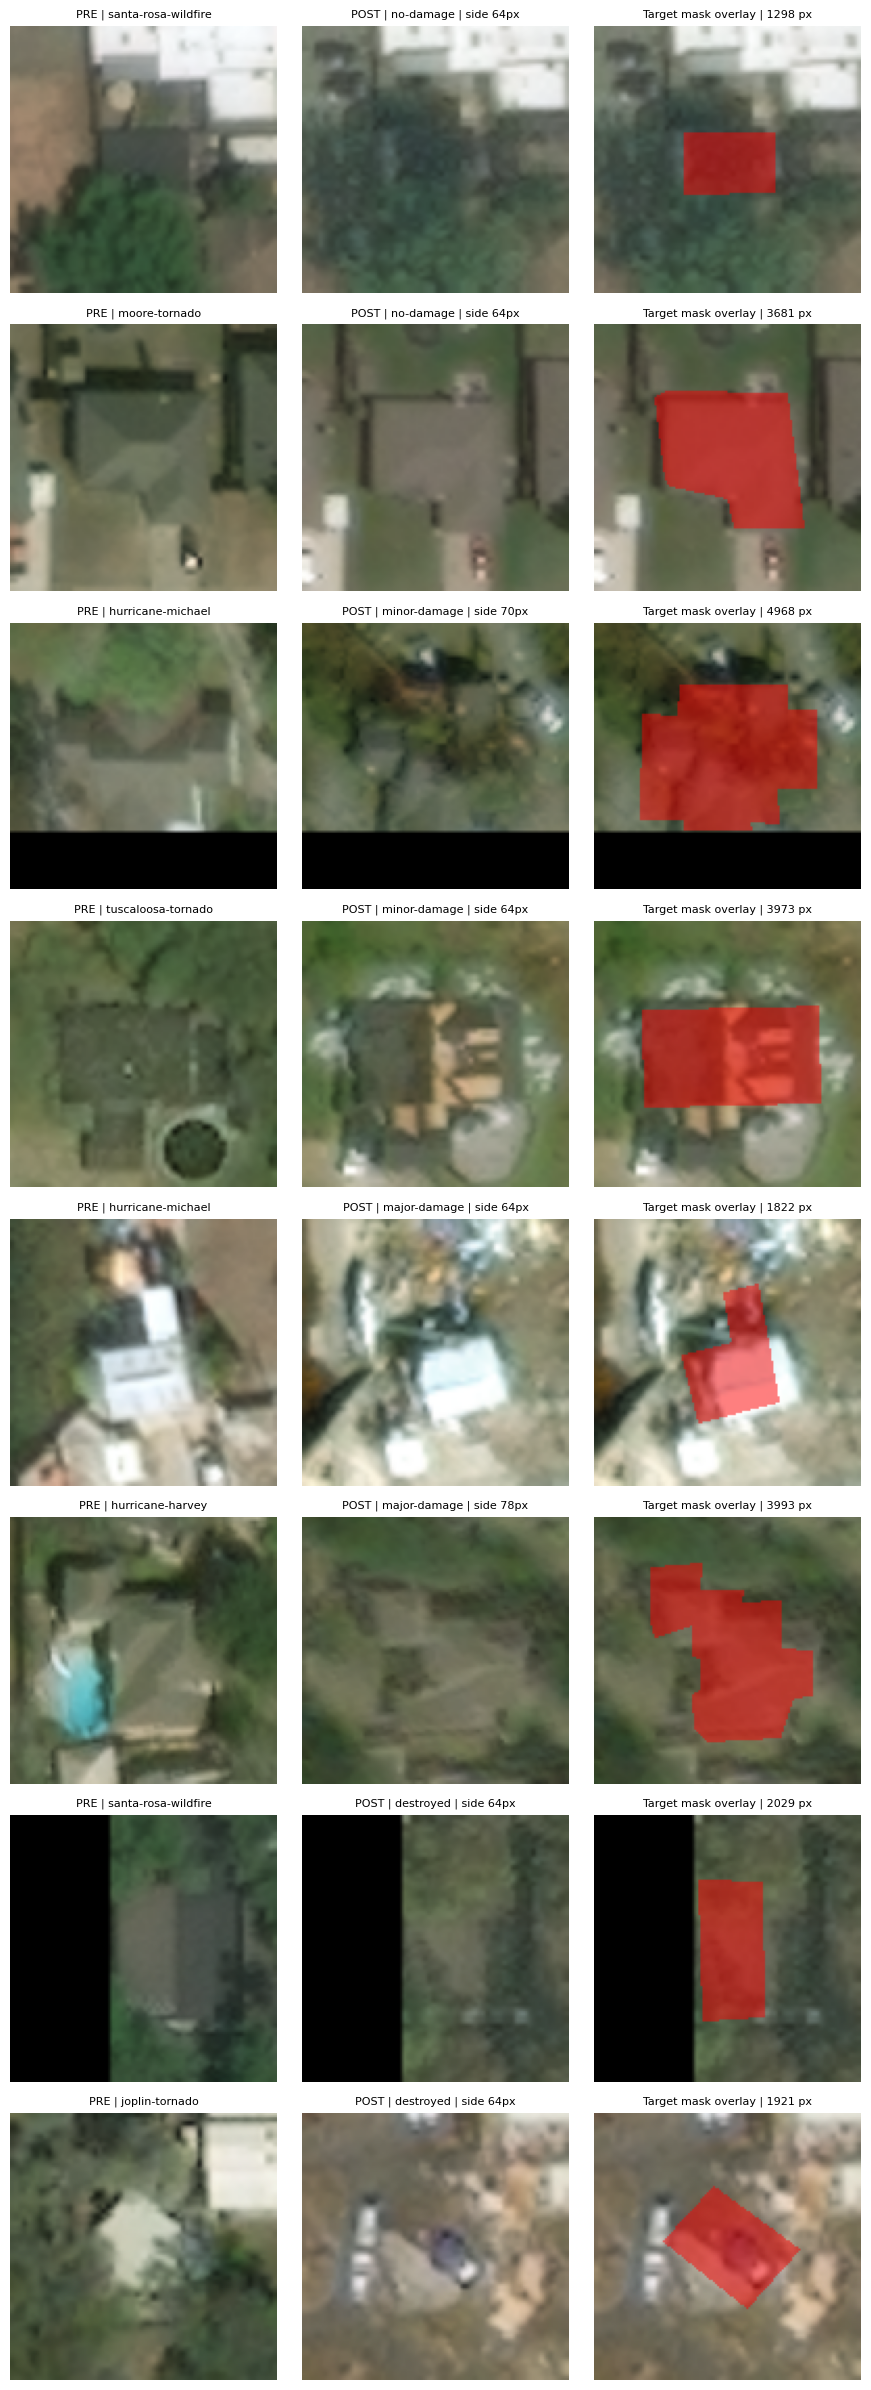

In [3]:
import cv2
import time
from shapely import wkt as shp_wkt
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

plan = pd.read_parquet(os.path.join(WORK_DIR, "crop_plan.parquet"))
OUT  = cfg["out_size"]

# Record the final interpolation / mask rules in the config
cfg["img_interp"]  = "INTER_LINEAR when enlarging, INTER_AREA when shrinking"
cfg["mask_method"] = "polygon shifted to crop coords, scaled, drawn directly at out_size"
with open(os.path.join(WORK_DIR, "crop_config.json"), "w") as f:
    json.dump(cfg, f, indent=2)

# key -> {"pre_img": path, "post_img": path}
key_to_paths = image_index.set_index("key")[["pre_img", "post_img"]].to_dict("index")

def read_rgb(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise IOError(f"Cannot read {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def crop_with_pad(img, x0, y0, side, pad_value=0):
    """Cut a side x side square starting at (x0, y0); parts outside
    the image are filled with pad_value."""
    H, W = img.shape[:2]
    out = np.full((side, side, img.shape[2]), pad_value, dtype=img.dtype)
    xs, ys = max(x0, 0), max(y0, 0)
    xe, ye = min(x0 + side, W), min(y0 + side, H)
    if xe > xs and ye > ys:
        out[ys - y0:ye - y0, xs - x0:xe - x0] = img[ys:ye, xs:xe]
    return out

def resize_img(crop):
    interp = cv2.INTER_AREA if crop.shape[0] > OUT else cv2.INTER_LINEAR
    return cv2.resize(crop, (OUT, OUT), interpolation=interp)

def target_mask(wkt_str, x0, y0, side):
    """Binary 128x128 mask with ONLY the target building = 1."""
    scale = OUT / side
    mask = np.zeros((OUT, OUT), dtype=np.uint8)
    geom = shp_wkt.loads(wkt_str)
    parts = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
    for g in parts:
        pts = (np.asarray(g.exterior.coords) - [x0, y0]) * scale
        cv2.fillPoly(mask, [np.round(pts).astype(np.int32)], 1)
    return mask

def process_image(args):
    """Read one image pair ONCE and build samples for all its
    selected buildings. Returns a list of
    (pos, pre_crop, post_crop, packed_mask, mask_pixel_count)."""
    key, rows = args
    paths = key_to_paths[key]
    pre, post = read_rgb(paths["pre_img"]), read_rgb(paths["post_img"])
    results = []
    for r in rows.itertuples(index=False):
        pre_c  = resize_img(crop_with_pad(pre,  r.crop_x0, r.crop_y0, r.crop_side, cfg["pad_value"]))
        post_c = resize_img(crop_with_pad(post, r.crop_x0, r.crop_y0, r.crop_side, cfg["pad_value"]))
        mask   = target_mask(r.wkt, r.crop_x0, r.crop_y0, r.crop_side)
        results.append((r.pos, pre_c, post_c, np.packbits(mask.reshape(-1)), int(mask.sum())))
    return results

# ---------------- Small test: 2 train buildings per class ----------------
test = (plan[plan["role"] == "train"]
        .groupby("label", group_keys=False)
        .apply(lambda d: d.sample(2, random_state=cfg["seed"]))
        .reset_index(drop=True))
test["pos"] = np.arange(len(test))

samples = {}
for key, rows in test.groupby("key"):
    for pos, pre_c, post_c, mpack, mpix in process_image((key, rows)):
        samples[pos] = (pre_c, post_c, np.unpackbits(mpack).reshape(OUT, OUT), mpix)

fig, axes = plt.subplots(len(test), 3, figsize=(9, 3 * len(test)))
for i, r in test.iterrows():
    pre_c, post_c, mask, mpix = samples[i]
    overlay = post_c.copy()
    overlay[mask == 1] = (0.5 * overlay[mask == 1] + [127, 0, 0]).astype(np.uint8)
    axes[i, 0].imshow(pre_c)
    axes[i, 1].imshow(post_c)
    axes[i, 2].imshow(overlay)
    axes[i, 0].set_title(f"PRE | {r['disaster']}", fontsize=8)
    axes[i, 1].set_title(f"POST | {r['subtype']} | side {r['crop_side']}px", fontsize=8)
    axes[i, 2].set_title(f"Target mask overlay | {mpix} px", fontsize=8)
    for a in axes[i]:
        a.axis("off")
plt.tight_layout()
plt.show()

# Cell 4:  Crop everything and write raw shards
-------------------------------------------------------------

Purpose : For each role (train, val):

           - give every building a position; shard = pos // 20000
           - pre-create raw .npy files with open_memmap
             ({role}_{shard}_pre / _post / _mask .npy)
           - crop with 16 threads (each image read once) and
             write each sample straight into its slot on disk
           - save {role}_index.parquet (label, shard, offset...)
           - write a {role}_DONE flag so a finished role is
             skipped if the cell is run again

 Output  : /kaggle/working/crops/  (~16.4 GB in total)


In [4]:

from numpy.lib.format import open_memmap

CROP_DIR  = os.path.join(WORK_DIR, "crops")
os.makedirs(CROP_DIR, exist_ok=True)
SHARD     = cfg["shard_size"]
N_WORKERS = 16
BATCH     = 64          # images submitted at a time (keeps RAM usage low)

for role in cfg["roles_in_this_notebook"]:
    done_flag = os.path.join(CROP_DIR, f"{role}_DONE")
    if os.path.exists(done_flag):
        print(f"[{role}] already done - skipped")
        continue

    df = (plan[plan["role"] == role]
          .sort_values(["key", "uid"]).reset_index(drop=True))
    df["pos"]    = np.arange(len(df))
    df["shard"]  = df["pos"] // SHARD
    df["offset"] = df["pos"] % SHARD
    n_shards = int(df["shard"].max()) + 1

    # ---- Pre-create raw shard files on disk ----
    shards = []
    for s in range(n_shards):
        n = int((df["shard"] == s).sum())
        base = os.path.join(CROP_DIR, f"{role}_{s:02d}")
        shards.append({
            "pre":  open_memmap(base + "_pre.npy",  mode="w+", dtype=np.uint8, shape=(n, OUT, OUT, 3)),
            "post": open_memmap(base + "_post.npy", mode="w+", dtype=np.uint8, shape=(n, OUT, OUT, 3)),
            "mask": open_memmap(base + "_mask.npy", mode="w+", dtype=np.uint8, shape=(n, OUT * OUT // 8)),
        })

    # ---- Crop in parallel, write each sample into its slot ----
    mask_pixels = np.zeros(len(df), dtype=np.int32)
    groups = list(df.groupby("key", sort=False))
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=N_WORKERS) as ex, \
         tqdm(total=len(groups), desc=f"Cropping {role}") as pbar:
        for i in range(0, len(groups), BATCH):
            for results in ex.map(process_image, groups[i:i + BATCH]):
                for pos, pre_c, post_c, mpack, mpix in results:
                    s, o = divmod(pos, SHARD)
                    shards[s]["pre"][o]  = pre_c
                    shards[s]["post"][o] = post_c
                    shards[s]["mask"][o] = mpack
                    mask_pixels[pos] = mpix
                pbar.update(1)

    for sh in shards:
        for arr in sh.values():
            arr.flush()
    del shards

    # ---- Save the role index and the DONE flag ----
    df["mask_pixels"] = mask_pixels
    df.to_parquet(os.path.join(CROP_DIR, f"{role}_index.parquet"), index=False)
    with open(done_flag, "w") as f:
        f.write("ok")
    print(f"[{role}] {len(df):,} samples in {n_shards} shard(s) "
          f"- {(time.time() - t0) / 60:.1f} min")

# ---- Total size on disk ----
total = sum(os.path.getsize(os.path.join(CROP_DIR, f)) for f in os.listdir(CROP_DIR))
print(f"\nTotal size of crops/: {total / 1e9:.2f} GB")

Cropping train:   0%|          | 0/4921 [00:00<?, ?it/s]

[train] 110,086 samples in 6 shard(s) - 4.5 min


Cropping val:   0%|          | 0/738 [00:00<?, ?it/s]

[val] 53,548 samples in 3 shard(s) - 1.4 min

Total size of crops/: 16.48 GB


# Cell 5: Verify the saved shards
-------------------------------------------------------------

 Purpose : Reload the shards read-only (memmap), check for
           empty masks or all-black crops, and show random
           saved samples per class with the target mask overlay.
           This is also how Phase 4 will read the data.

 Output  : Printed checks + /kaggle/working/crops_check.png



=== train: 110,086 samples ===
Label counts: {0: 40000, 1: 25598, 2: 21362, 3: 23126}
Empty target masks : 0
Mask pixels (median / 5% / 95%): 2213.0 360.0 4703.0
All-black post crops in 500 random samples: 0

=== val: 53,548 samples ===
Label counts: {0: 41193, 1: 4780, 2: 3833, 3: 3742}
Empty target masks : 0
Mask pixels (median / 5% / 95%): 2392.0 427.0 4740.0
All-black post crops in 500 random samples: 0


/tmp/ipykernel_16/2396357451.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d.sample(3, random_state=1))


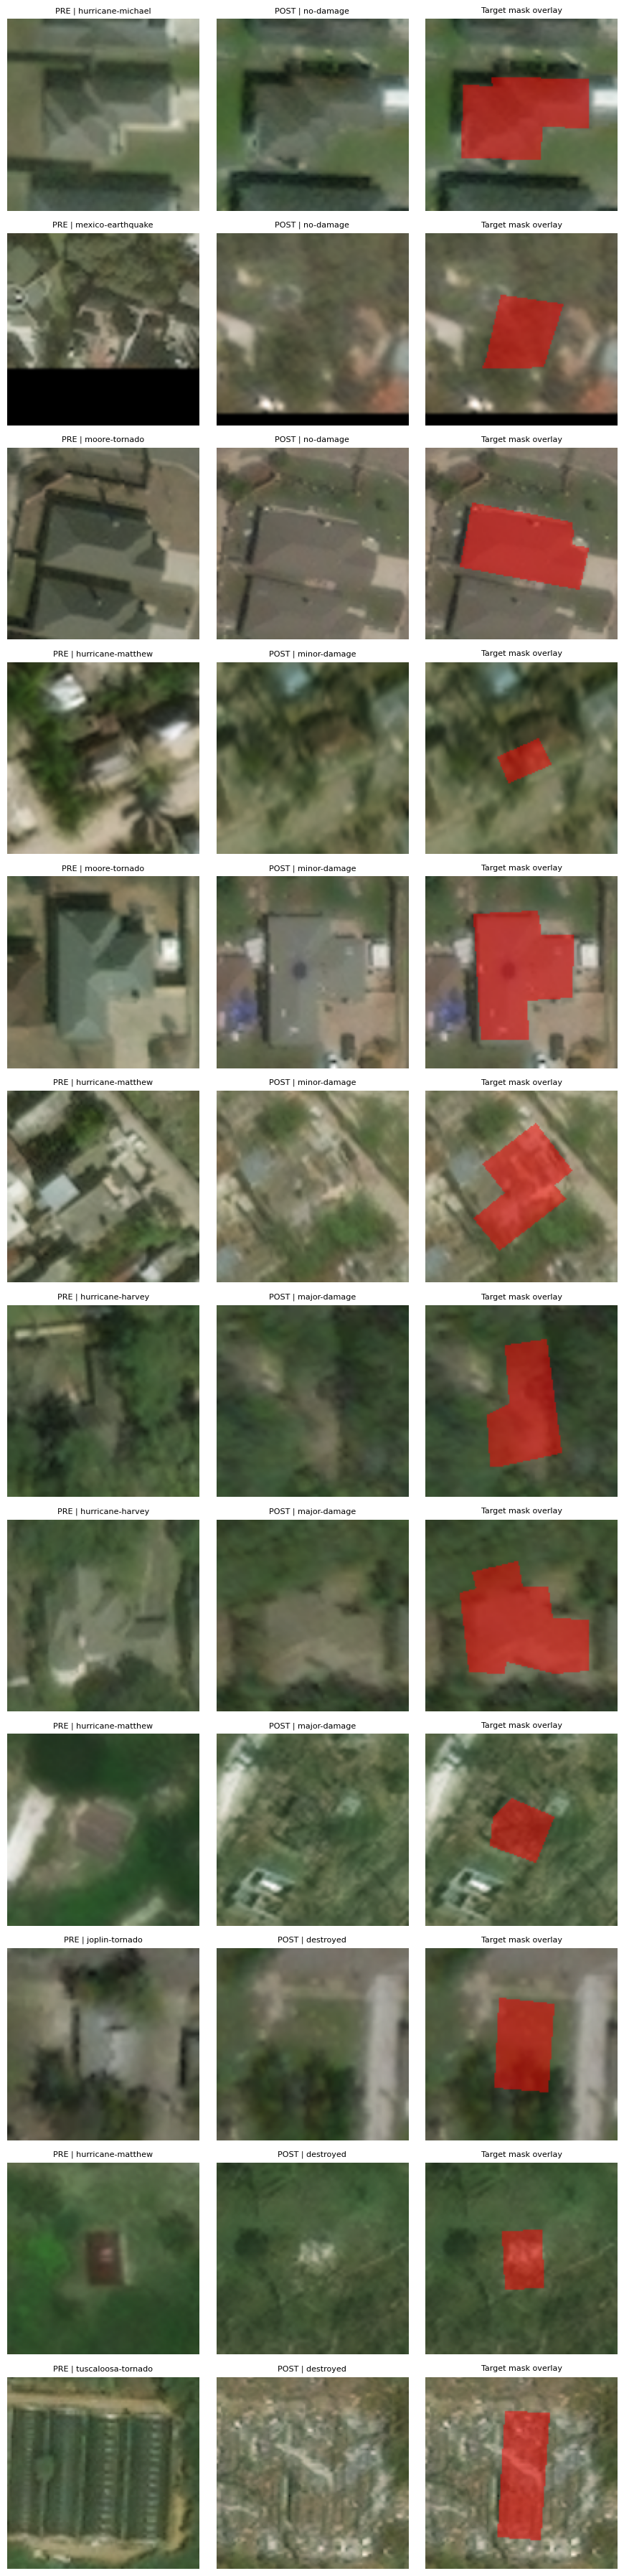

In [5]:

def open_role(role):
    idx = pd.read_parquet(os.path.join(CROP_DIR, f"{role}_index.parquet"))
    n_shards = int(idx["shard"].max()) + 1
    arrays = []
    for s in range(n_shards):
        base = os.path.join(CROP_DIR, f"{role}_{s:02d}")
        arrays.append({k: np.load(f"{base}_{k}.npy", mmap_mode="r")
                       for k in ("pre", "post", "mask")})
    return idx, arrays

for role in cfg["roles_in_this_notebook"]:
    idx, arrays = open_role(role)
    print(f"\n=== {role}: {len(idx):,} samples ===")
    print("Label counts:", idx["label"].value_counts().sort_index().to_dict())
    print(f"Empty target masks : {(idx['mask_pixels'] == 0).sum():,}")
    print("Mask pixels (median / 5% / 95%):",
          idx["mask_pixels"].median(),
          idx["mask_pixels"].quantile(0.05),
          idx["mask_pixels"].quantile(0.95))

    # Check a random subset for all-black crops
    chk = idx.sample(500, random_state=0)
    black = sum(arrays[r.shard]["post"][r.offset].max() == 0 for r in chk.itertuples())
    print(f"All-black post crops in 500 random samples: {black}")

# ---- Show 3 random saved train samples per class ----
idx, arrays = open_role("train")
show = (idx.groupby("label", group_keys=False)
        .apply(lambda d: d.sample(3, random_state=1))
        .reset_index(drop=True))

fig, axes = plt.subplots(len(show), 3, figsize=(9, 3 * len(show)))
for i, r in show.iterrows():
    a = arrays[r["shard"]]
    pre_c  = np.asarray(a["pre"][r["offset"]])
    post_c = np.asarray(a["post"][r["offset"]])
    mask   = np.unpackbits(a["mask"][r["offset"]]).reshape(OUT, OUT)
    overlay = post_c.copy()
    overlay[mask == 1] = (0.5 * overlay[mask == 1] + [127, 0, 0]).astype(np.uint8)
    axes[i, 0].imshow(pre_c)
    axes[i, 1].imshow(post_c)
    axes[i, 2].imshow(overlay)
    axes[i, 0].set_title(f"PRE | {r['disaster']}", fontsize=8)
    axes[i, 1].set_title(f"POST | {r['subtype']}", fontsize=8)
    axes[i, 2].set_title("Target mask overlay", fontsize=8)
    for ax in axes[i]:
        ax.axis("off")
plt.tight_layout()
fig.savefig(os.path.join(WORK_DIR, "crops_check.png"), dpi=120, bbox_inches="tight")
plt.show()